## PDF for median-based methods

In this notebook, I plot the histogram of n=1000 noise realizations and compare it with the theoretical PDF for mean-based method.

In [1]:
import os as os
import sys
import numpy as np

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)

import math as math

from scripts.readTdi import readTdi, getTdiPath
from psd_estimation_methods.wosa import wosa
from psd_estimation_methods.lpsd import lpsd
from scripts.psdNoise import n_time_noise_from_psd, n_noise_psds, compute_psd_noise_distribution
from scripts.plot import plot, plot_psd_noise_median_histogram,  plot_psd_noise_median_histogram_two_cross_two, plot_median_vs_mean_pdf, plot_median_vs_mean_pdf_two_cross_two
from scripts.medianFuncs import confidence_interval, median_pdf, factor
from scripts.pdf import pdf                         
import matplotlib.pyplot as plt
from scipy.integrate import simpson

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

def plot_matched_std(N_mean, s=1.0, N_candidates=None, x_max_factor=50, npts=20000):
    """
    Plot WOSA-mean PDF at N_mean and the *scaled* WOSA-median PDF at the
    N in N_candidates whose std (after scaling to mean=s) is closest to the mean's std.

    Assumes you already have:
      - pdf(x, N, s, mode="mean"|"median")
      - median_pdf(x, N, s)
    """
    if N_candidates is None:
        N_candidates = range(1, 201)

    # wide grid so scaling doesn't truncate tails
    x = np.linspace(0, x_max_factor * s, npts)

    # --- mean curve (no scaling needed; its mean is s by construction)
    p_mean = pdf(x, N_mean, s, "mean")
    # analytic std for the mean-of-N exponentials (Gamma): s / sqrt(N)
    std_mean = s / np.sqrt(N_mean)
    # (Optional numeric check if you want)
    # m1_mean = simpson(x * p_mean, x=x); m2_mean = simpson(x**2 * p_mean, x=x)
    # std_mean = np.sqrt(max(m2_mean - m1_mean**2, 0.0))

    # --- search for median N with matched std (AFTER scaling to mean s)
    best = None
    for N_med in N_candidates:
        # unscaled median
        p_med_unscaled = pdf(x, N_med, s, "median")
        m1_unscaled = simpson(x * p_med_unscaled, x=x)

        # scale so mean == s: x -> x/c  with  c = s / m1_unscaled
        c = s / m1_unscaled
        p_med_scaled = median_pdf(x / c, N_med, s) / c

        # moments AFTER scaling (use numeric mean to be robust)
        m1 = simpson(x * p_med_scaled, x=x)
        m2 = simpson((x**2) * p_med_scaled, x=x)
        std_med = np.sqrt(max(m2 - m1**2, 0.0))

        diff = abs(std_med - std_mean)
        if (best is None) or (diff < best["diff"]):
            best = dict(N_med=N_med, p_med=p_med_scaled, mean_med=m1,
                        std_med=std_med, diff=diff)

    # --- plot
    plt.figure(figsize=(8, 4))
    line_mean, = plt.plot(x, p_mean, lw=2,
                          label=f"WOSA PDF (N={N_mean}, σ={std_mean:.3f})")
    line_med,  = plt.plot(x, best["p_med"], lw=2,
                          label=f"WOSA-Median PDF (N={best['N_med']}, σ={best['std_med']:.3f})")
    plt.xlim(0, 3*s)
    plt.ylim(bottom=0)
    plt.axvline(s, ls='--', lw=2, label=f"Mean of both = {s}")

    plt.xlabel("x")
    plt.ylabel("PDF")
    plt.title(f"Matched-σ PDFs (PSD={s}): mean N={N_mean} vs median N={best['N_med']}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {"N_mean": N_mean, "std_mean": std_mean,
            "N_med": best["N_med"], "std_med": best["std_med"],
            "abs_diff": best["diff"]}

The median PDF is wider than the mean PDF. So, to match the standard deviation of the mean, the median-based method needs more data. The plots below show that it takes about 30–100% more data for the median than for the mean.

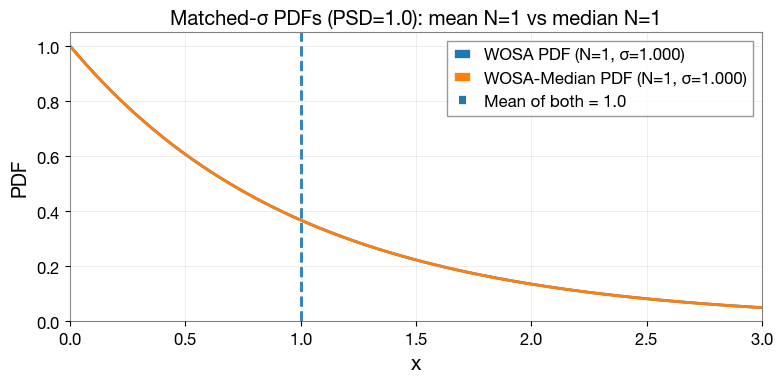

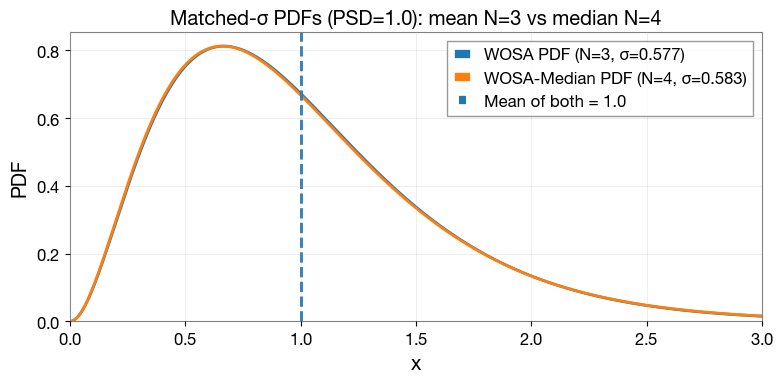

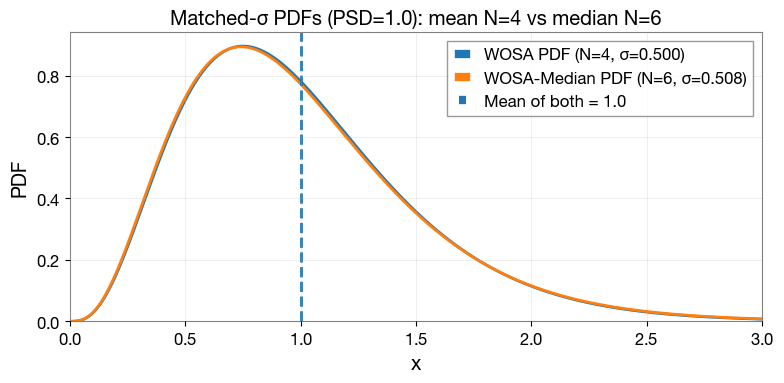

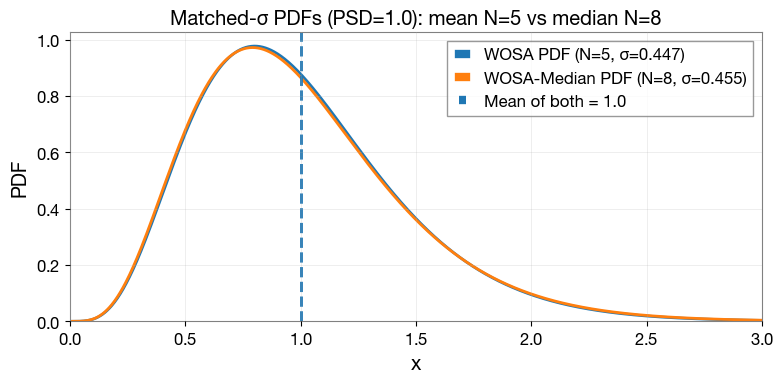

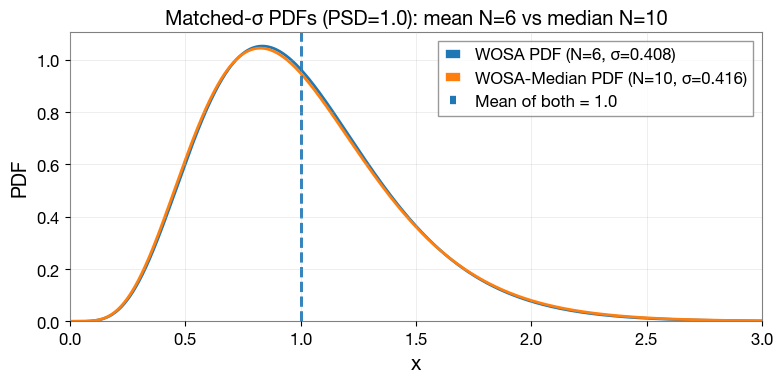

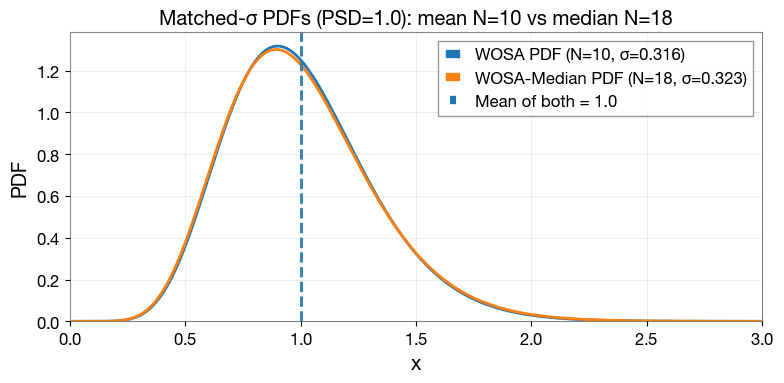

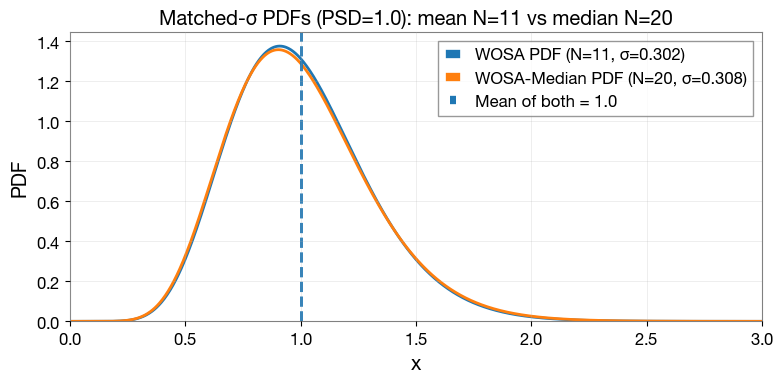

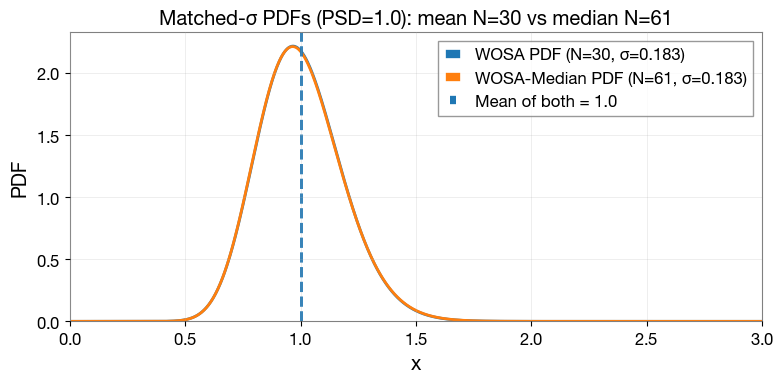

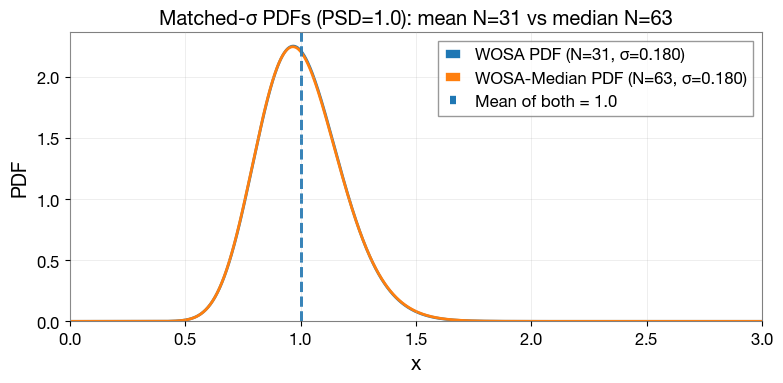

In [4]:
for N in (1, 3, 4, 5, 6, 10, 11, 30, 31):
   plot_matched_std(N_mean=N, s=1.0, N_candidates=range(1, 100))

The following plot is the the median and mean PDF when the psd_true=1. Observe that median underestimates the PSD

[1.00000000e+00 9.97502998e-01 9.95012230e-01 ... 1.93841823e-22
 1.93357800e-22 1.92874985e-22]
[0.00000000e+00 8.37528983e-05 3.32508280e-04 ... 2.45770282e-61
 2.43958206e-61 2.42159489e-61]
[0.00000000e+000 7.29844010e-022 7.27086882e-019 ...
 1.11363931e-217 1.08397192e-217 1.05509484e-217]
[0.00000000e+00 7.50611305e-63 3.73861944e-54 ... 0.00000000e+00
 0.00000000e+00 0.00000000e+00]


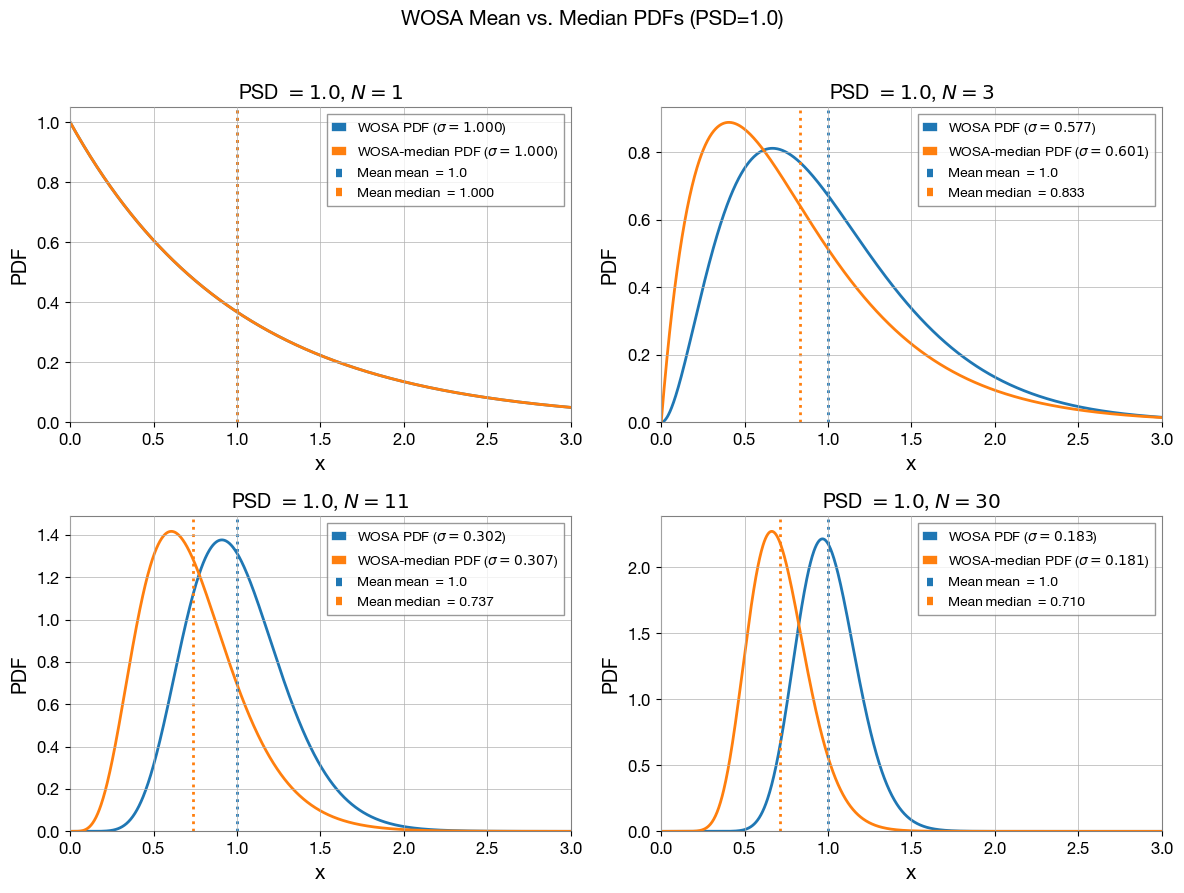

In [5]:
plot_median_vs_mean_pdf_two_cross_two(
    N_values=(1, 3, 11, 30),  # any four segment counts
    s=1.0,
    mode="unscaled"             # or "unscaled"
)

We can correct the curve by multiplying the median curve with a factor 

[1.00000000e+00 9.97502998e-01 9.95012230e-01 ... 1.93841823e-22
 1.93357800e-22 1.92874985e-22]
[0.00000000e+00 8.37528983e-05 3.32508280e-04 ... 2.45770282e-61
 2.43958206e-61 2.42159489e-61]
[0.00000000e+000 7.29844010e-022 7.27086882e-019 ...
 1.11363931e-217 1.08397192e-217 1.05509484e-217]
[0.00000000e+00 7.50611305e-63 3.73861944e-54 ... 0.00000000e+00
 0.00000000e+00 0.00000000e+00]


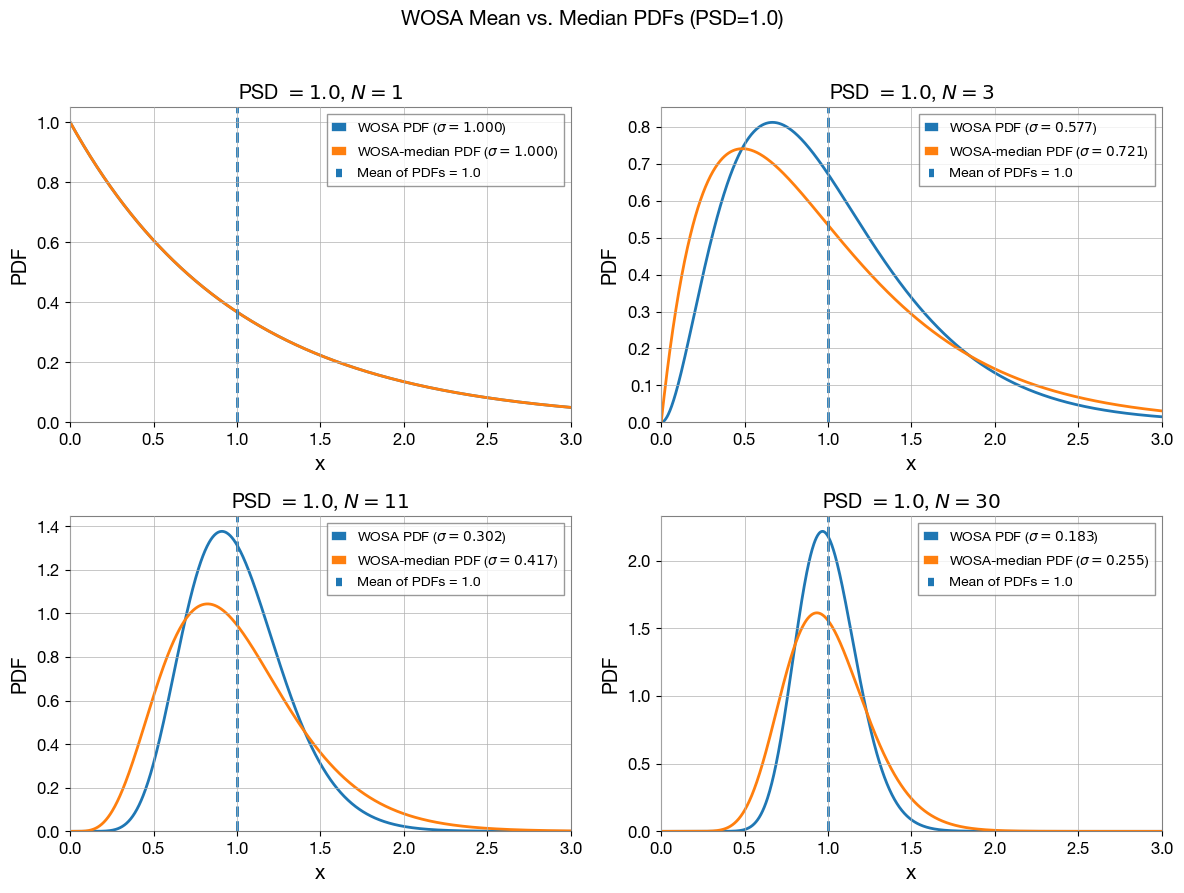

In [6]:
plot_median_vs_mean_pdf_two_cross_two(
    N_values=(1, 3, 11, 30),  # any four segment counts
    s=1.0,
    mode="scaled"             # or "unscaled"
)

Here are some more scaled median curve along with mean curve for no reason:

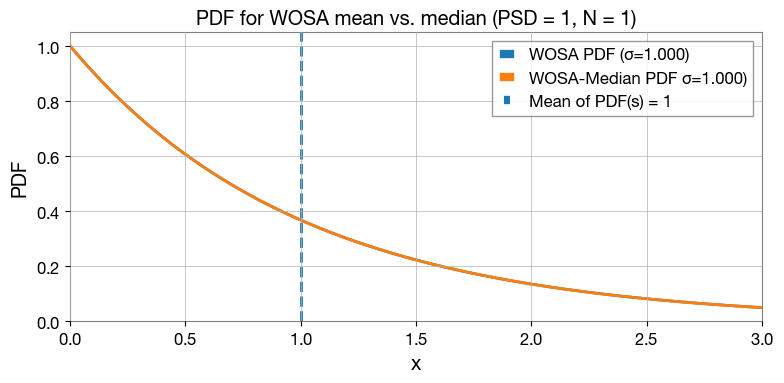

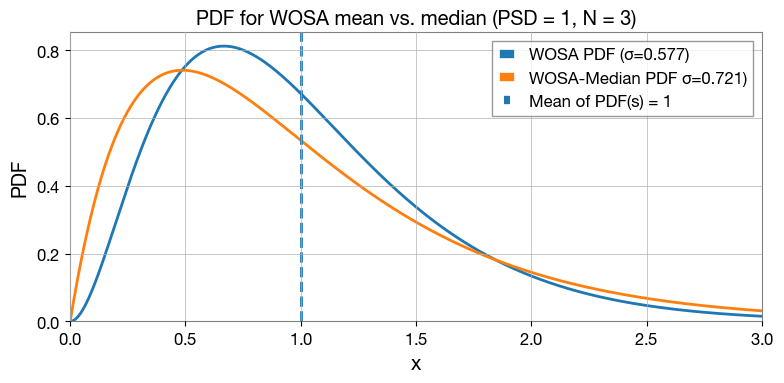

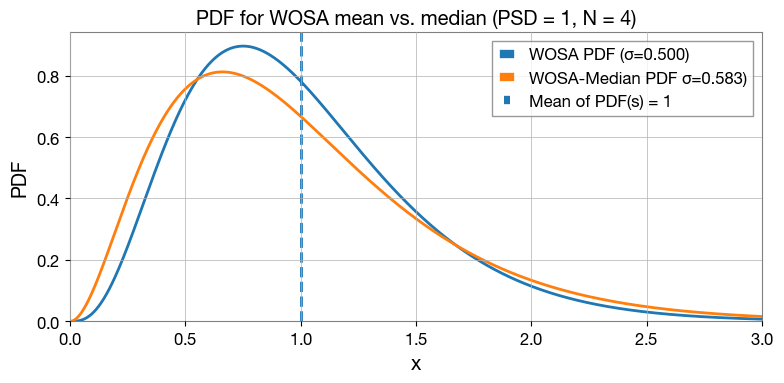

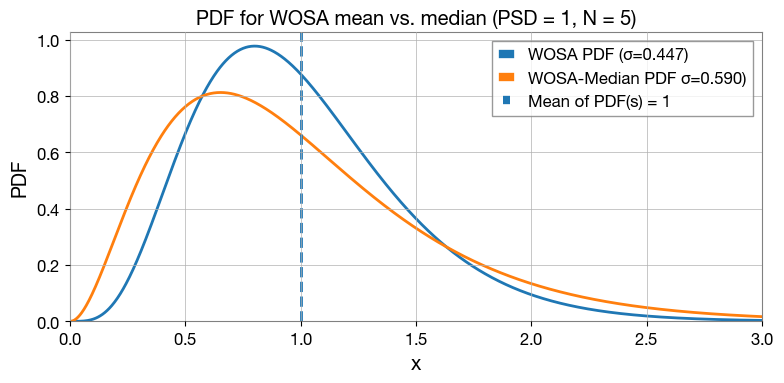

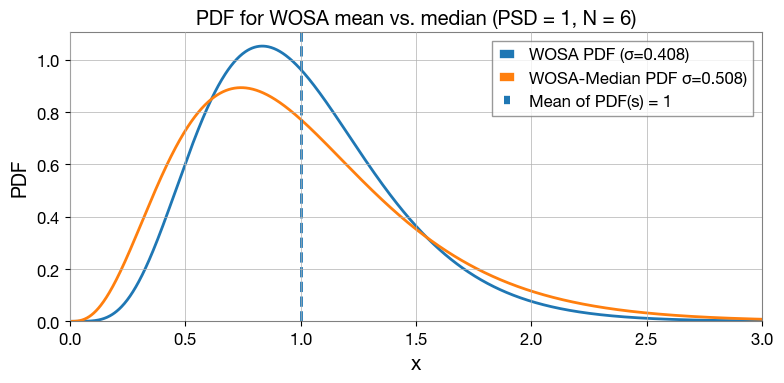

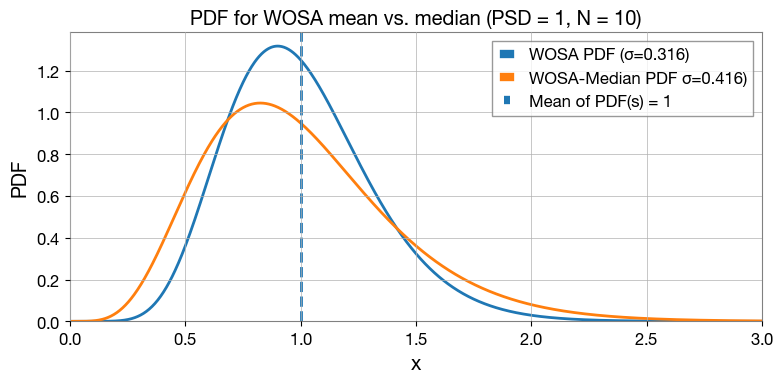

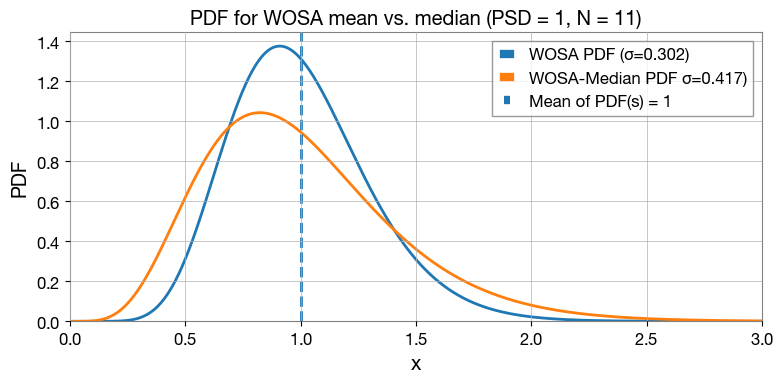

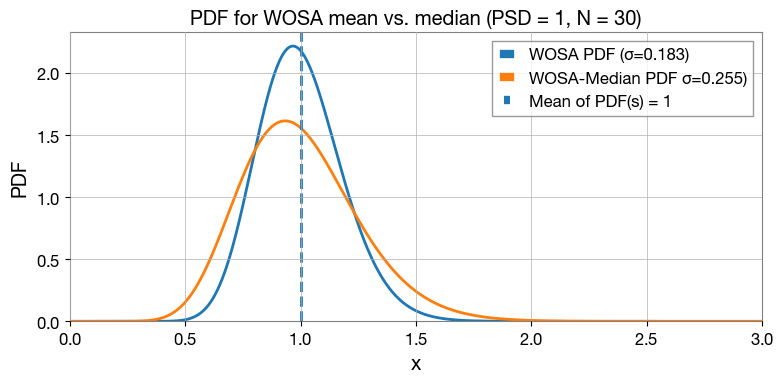

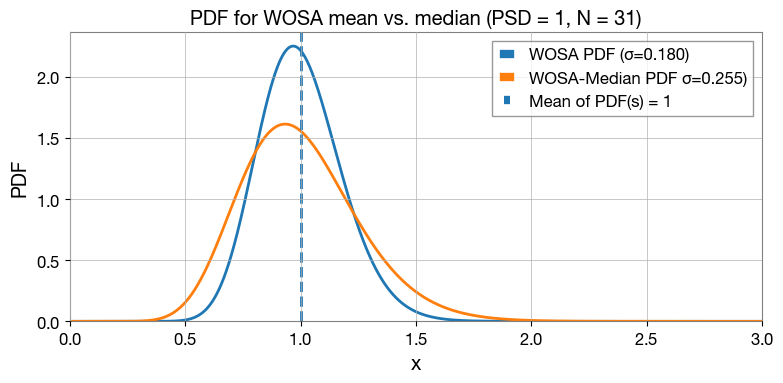

In [7]:
for N in (1, 3, 4, 5, 6, 10, 11, 30, 31):
    plot_median_vs_mean_pdf(N, s=1, mode="scaled")

some more unscaled median and mean PDFs for no reason: 

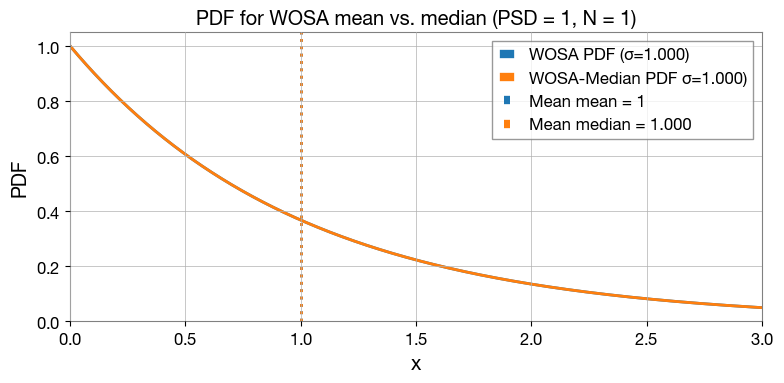

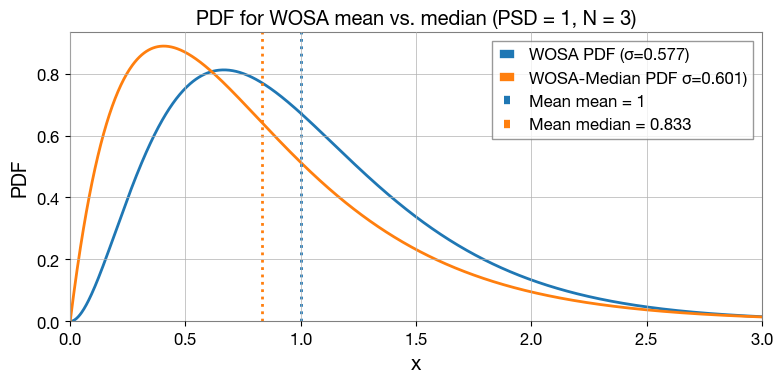

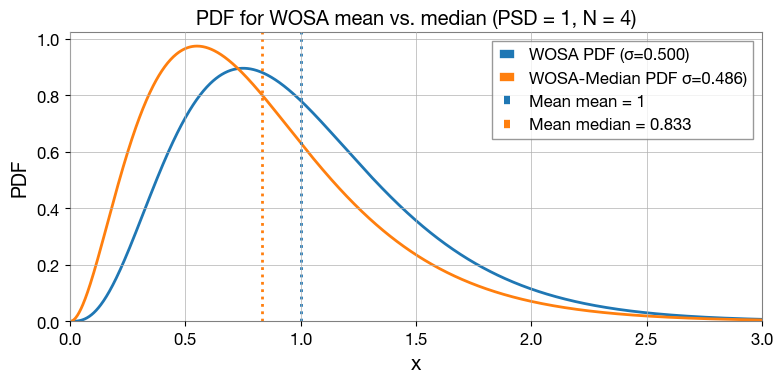

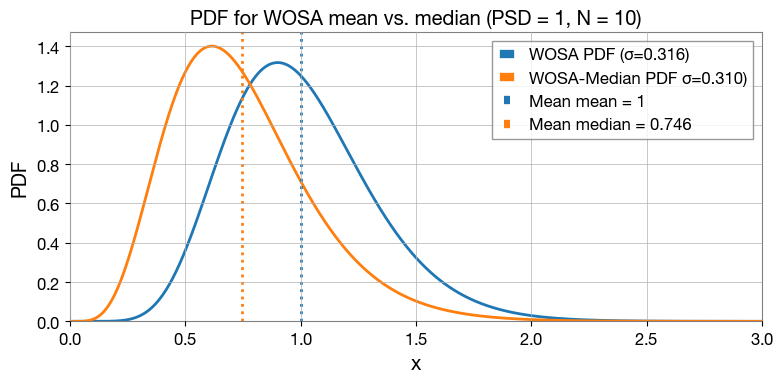

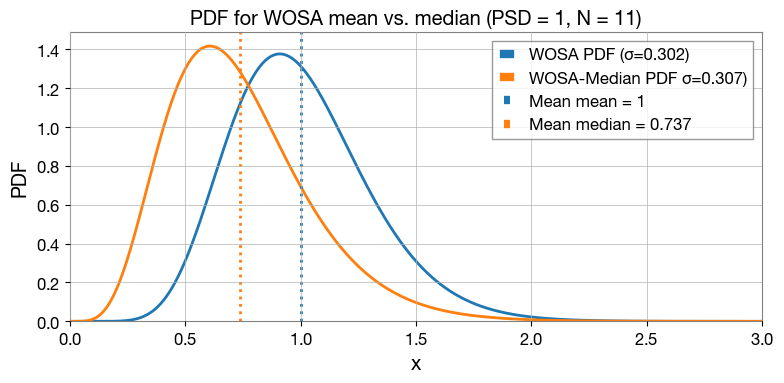

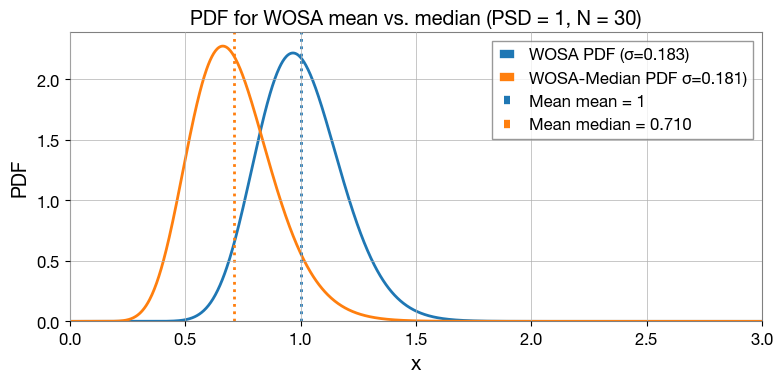

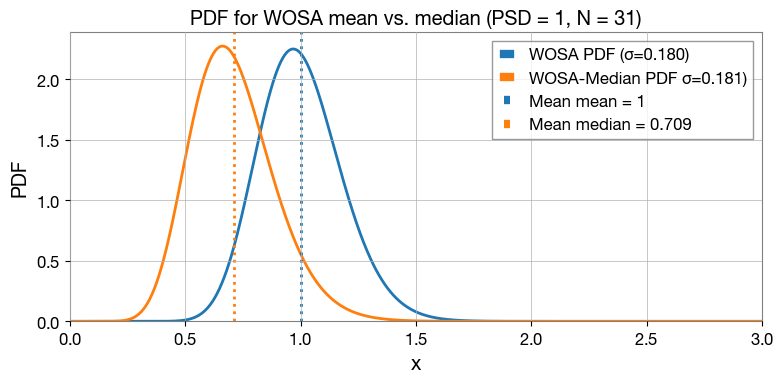

In [8]:
for N in (1, 3, 4, 10, 11, 30, 31):
    plot_median_vs_mean_pdf(N, s=1, mode="unscaled")

In [9]:
# 1) Read the TDI time series
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg
) 

#plot(data, t, fs, f_orig, orig_psd,  nperseg, title="TDI-X", bigtitle="PSD graphs")

# 3) generate n time-domain noise realisations such that PSD equals "PSD OF TDI time series "
time_noises = n_time_noise_from_psd(
    orig_psd, 
    fs, 
    nperseg, 
    n=1000,
    seed_offset=0
)

This plot shows that our theoretical median PDF is correct (cuz it aligns with the histogram)

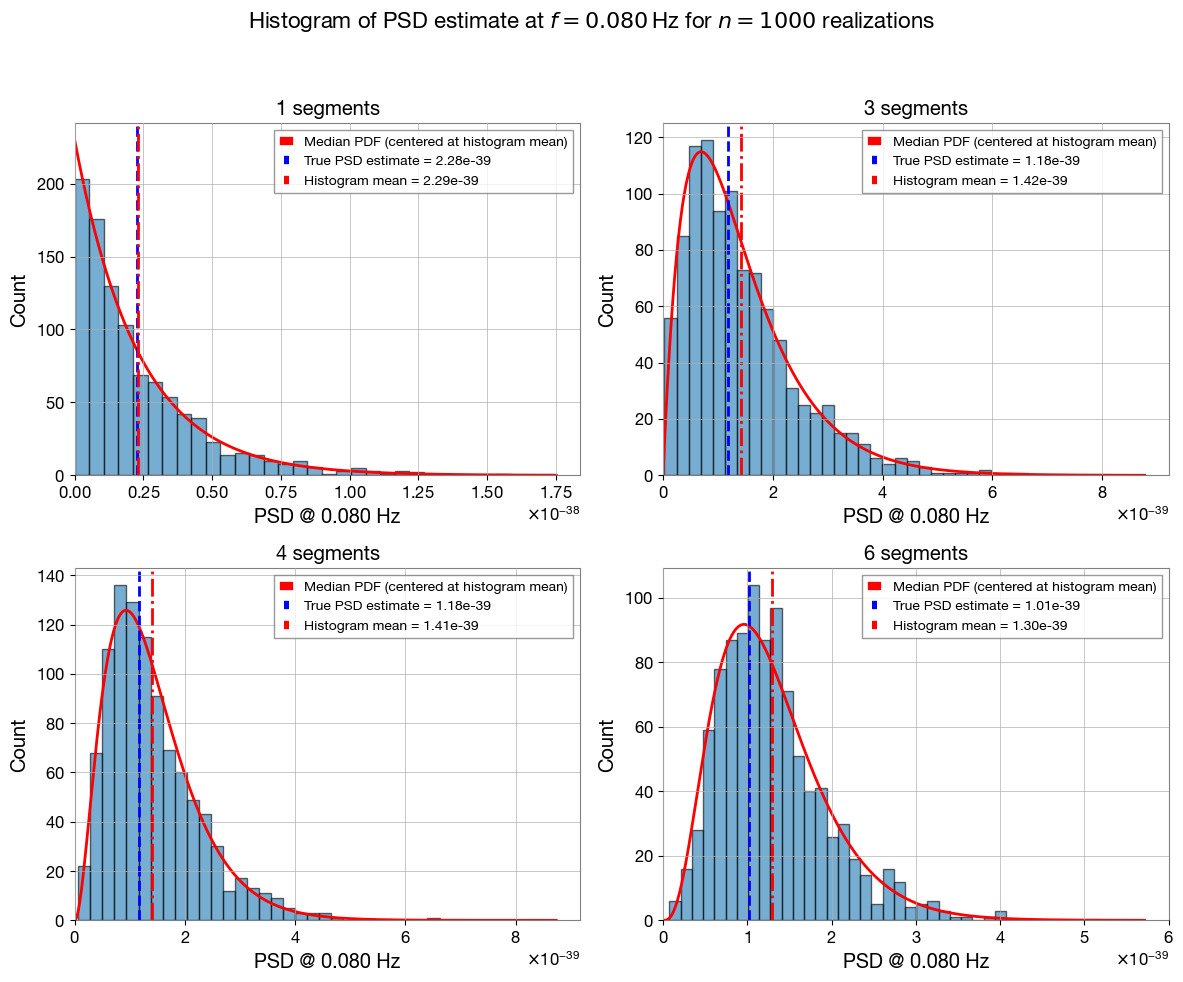

In [11]:
fraction     = 0.8
noverlap     = 0
nperseg_list = [20000, 6000, 5000, 3000]

noise_vals_list = []
freq_list       = []
N_list          = []
seg_counts      = []

for nperseg in nperseg_list:
    f_noise, noise_psds, nseg = n_noise_psds(
        time_noises, fs, nperseg,
        noverlap=noverlap,
        method='median'
    )
    psd_vals, orig_val, chosen_freq, _ = compute_psd_noise_distribution(
        orig_psd, f_orig, noise_psds, f_noise,
        fraction=fraction
    )
    noise_vals_list.append(psd_vals)
    freq_list.append(chosen_freq)
    N_list.append(nseg[0])
    seg_counts.append(nseg[0])

main_title = (
    fr"Histogram of PSD estimate at $f={freq_list[0]:.3f}\,$Hz "
    fr"for $n={len(noise_vals_list[0])}$ realizations"
)

plot_psd_noise_median_histogram_two_cross_two(
    noise_vals_list,
    freq_list,
    N_list,
    seg_counts,
    median_pdf_fn=median_pdf,
    main_title=main_title,
    n_bins=30,
    show_biased_hist=False
)

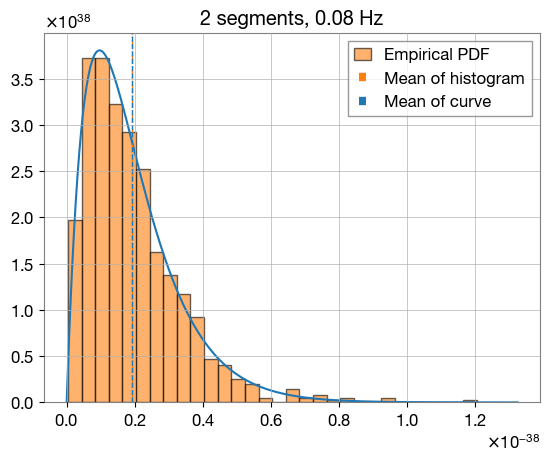

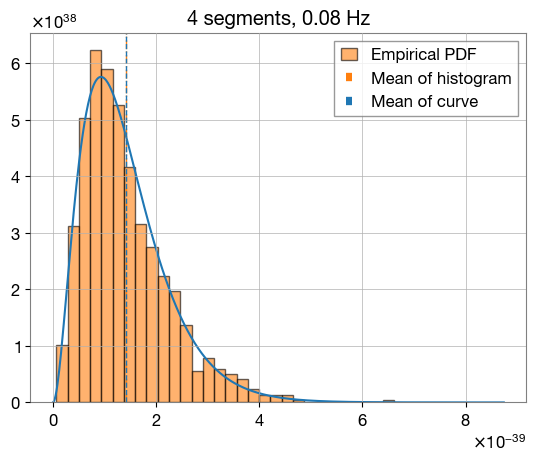

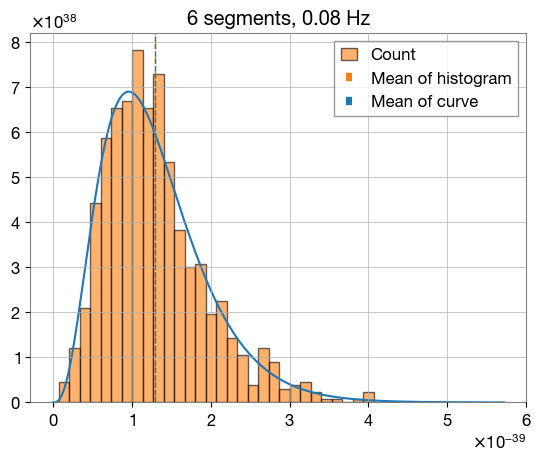

In [13]:
noverlap = 0
fraction = 0.8

nperseg_noise = 10000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

mean_histogram = np.mean(psd_noise_vals)
x = np.linspace(0, psd_noise_vals.max() * 1.1, 500)
N   = nseg[0]                 
pdf = median_pdf(x, N, mean_histogram)
pdf /= np.trapz(pdf, x)   
curve_mean = np.trapz(x * pdf, x)
scale_fac = mean_histogram / curve_mean

x *= scale_fac
pdf /= scale_fac
curve_mean = np.trapz(x * pdf, x)

plt.plot(x, pdf)
plt.hist(psd_noise_vals, bins=30, density=True,
            alpha=0.6, edgecolor='k', label='Empirical PDF')
plt.axvline(mean_histogram, linestyle='-.', color='tab:orange', linewidth=1, label="Mean of histogram")
plt.axvline(curve_mean, linestyle='--', color='C0', linewidth=1, label="Mean of curve")
plt.legend()
plt.title(f'{N} segments, {chosen_f_orig} Hz')
plt.show()


nperseg_noise = 5000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

mean_histogram = np.mean(psd_noise_vals)
x = np.linspace(0, psd_noise_vals.max() * 1.1, 500)
N   = nseg[0]                 
pdf = median_pdf(x, N, mean_histogram)
pdf /= np.trapz(pdf, x)   
curve_mean = np.trapz(x * pdf, x)
scale_fac = mean_histogram / curve_mean

x *= scale_fac
pdf /= scale_fac
curve_mean = np.trapz(x * pdf, x)

plt.plot(x, pdf)
plt.hist(psd_noise_vals, bins=30, density=True,
            alpha=0.6, edgecolor='k', label='Empirical PDF')
plt.axvline(mean_histogram, linestyle='-.', color='tab:orange', linewidth=1, label="Mean of histogram")
plt.axvline(curve_mean, linestyle='--', color='C0', linewidth=1, label="Mean of curve")
plt.legend()
plt.title(f'{N} segments, {chosen_f_orig} Hz')
plt.show()


[10 10 10 ... 10 10 10]


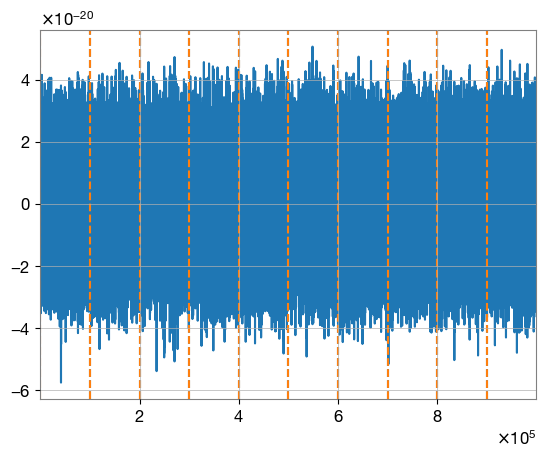

(<Figure size 500x400 with 1 Axes>,
 [<Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>])

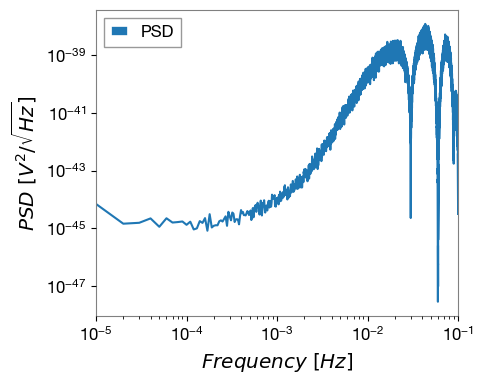

In [18]:
def draw_segments(t, data, nperseg, noverlap):
    N = len(data)
    step = nperseg - noverlap
    starts = np.arange(0, N, step)

    plt.figure()
    plt.plot(t, data)
    plt.xlim(t[0], t[-1])

    for start in starts:
        # always draw the start line
        plt.axvline(t[start], color='C1', linestyle='--')
        # only draw an end line if it falls inside the data
        end = start + nperseg
        if end < N:
            plt.axvline(t[end], color='C0', linestyle='--')

    plt.show()

# 1) Read the TDI time series
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
# nperseg = nperseg * 10
f_orig, orig_psd, P_stack, nseg = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg,
    noverlap=0
) 
f_orig, orig_psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
print(nseg)
# Plot the original psd for no reason 
# draw_segments(t, data, nperseg, 0)
draw_segments(t, data, nperseg, 0)

plot(data=data, t=t, f=f_orig, psd=[orig_psd_median], labels=["PSD"], title="TDI-X", show_time_series=False, f_lims=[f_orig[1], f_orig[-1]])

Text(0, 0.5, 'Amplitude')

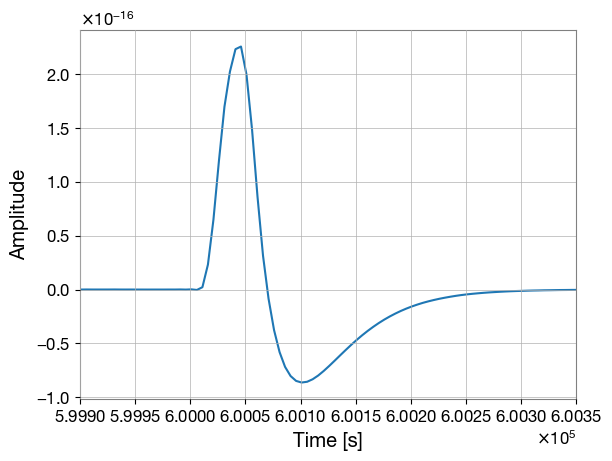

In [19]:
# 1) Read the TDI time series
tdi_path = getTdiPath('large_glitch_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_orig, orig_psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
# Plot the original psd for no reason 
# plot(
#     data=data,
#     t=t, 
#     fs=fs, 
#     f=f_orig, 
#     nper=nperseg, 
#     psd= [orig_psd, orig_psd_mean],
#     labels= ["no glitch", "glitch"],
#     title="TDI-X", 
#     bigtitle="PSD graphs"
# )

import matplotlib.pyplot as plt
plt.plot(t, data)

plt.xlim(600000-100, 600000+350)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

## Comparing the effect of a glitch on mean and median based method:

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

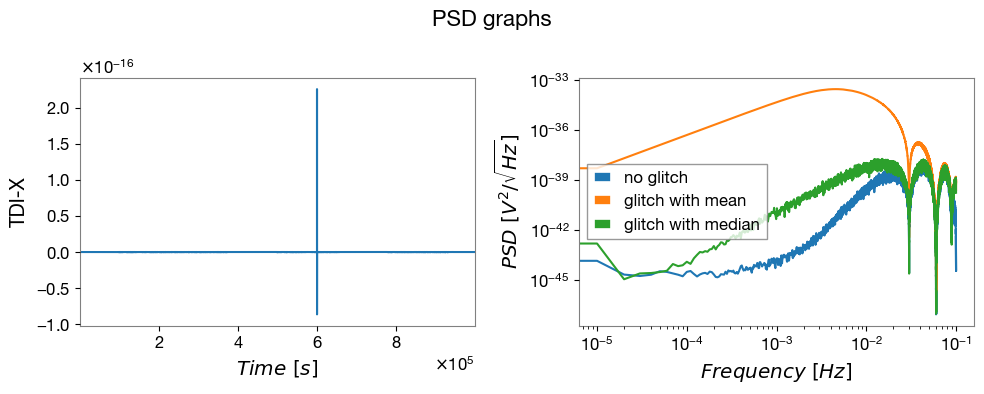

In [20]:
# 1) Read the TDI time series
tdi_path = getTdiPath('large_glitch_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_orig, orig_psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
# Plot the original psd for no reason 
plot(
    data=data,
    t=t, 
    f=f_orig, 
    psd= [orig_psd, orig_psd_mean, orig_psd_median],
    labels= ["no glitch", "glitch with mean", "glitch with median"],
    title="TDI-X", 
    bigtitle="PSD graphs"
)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

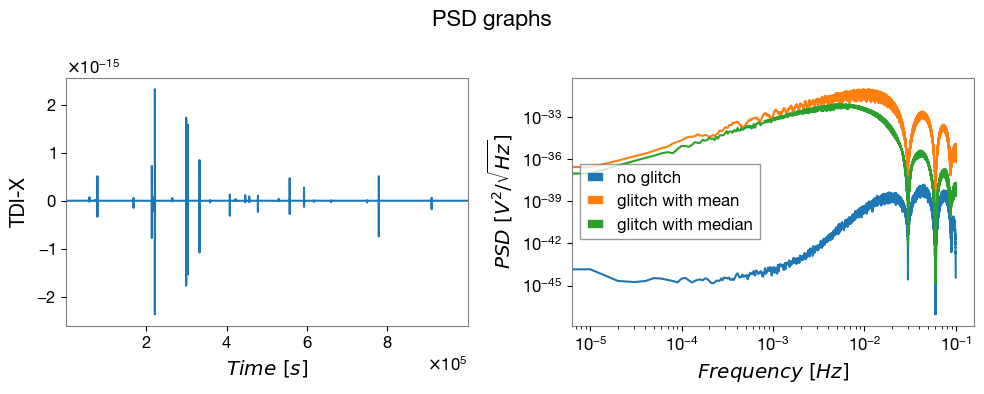

In [21]:
# 1) Read the TDI time series
tdi_path = getTdiPath('large_glitch_pos_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_orig, orig_psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
# Plot the original psd for no reason 
plot(
    data=data,
    t=t, 
    f=f_orig, 
    psd= [orig_psd, orig_psd_mean, orig_psd_median],
    labels= ["no glitch", "glitch with mean", "glitch with median"],
    title="TDI-X", 
    bigtitle="PSD graphs"
)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

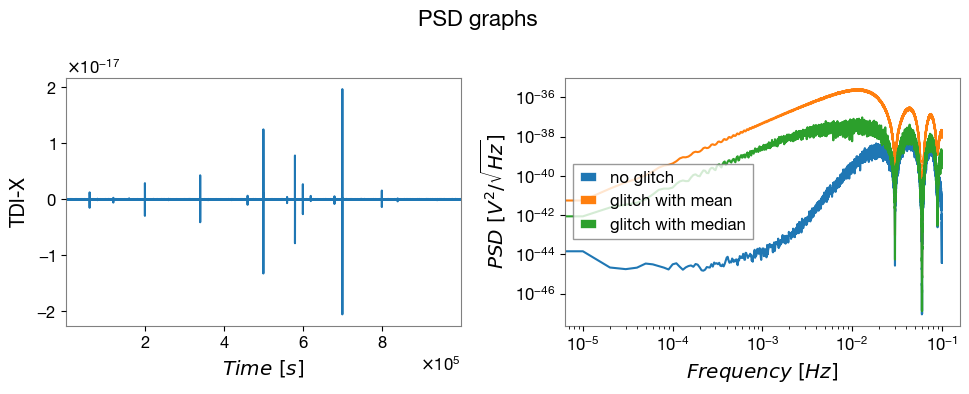

In [22]:

# 1) Read the TDI time series
tdi_path = getTdiPath('medium_glitch_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_orig, orig_psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
# Plot the original psd for no reason 
plot(
    data=data,
    t=t, 
    f=f_orig, 
    psd= [orig_psd, orig_psd_mean, orig_psd_median],
    labels= ["no glitch", "glitch with mean", "glitch with median"],
    title="TDI-X", 
    bigtitle="PSD graphs"
)

